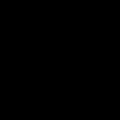

In [21]:
import pixie
import PIL
import matplotlib.pyplot as plt
import numpy as np

def save_image(image, filename):
    """Helper function to save the image as grayscale and render it in notebook.
    """
    image.write_file(filename)
    img = PIL.Image.open(filename) 
    img = PIL.ImageOps.grayscale(img)
    img.save(filename)
    return img
    
# image size
nx, ny = (120, 120)

# Black = semiconductor
BLACK = pixie.Color(0, 0, 0, 1)
WHITE = pixie.Color(1, 1, 1, 1)  # White
GREY  = pixie.Color(0.5, 0.5, 0.5, 1)  # GREY

# Anything black is semiconductor
SEMICONDUCTOR_PAINT = pixie.Paint(pixie.SOLID_PAINT)
SEMICONDUCTOR_PAINT.color = BLACK

# Anything white is bus-bar (connects to voltage source)
BUS_PAINT = pixie.Paint(pixie.SOLID_PAINT)
BUS_PAINT.color = WHITE

# Anything grey is grid-finger (connects to bus bar)
FINGER_PAINT = pixie.Paint(pixie.SOLID_PAINT)
FINGER_PAINT.color = GREY

# Start of with a black canvas
image = image = pixie.Image(nx, ny)
image.fill(BLACK)
save_image(image, "img1.bmp")

Start with an empty semiconductor surface. We can now draw the mask on top. We going to draw where we want metal, so the opposite way of thinking about the problem from processing perspective.

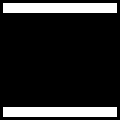

In [22]:
bus_px = 10
offset_px = 3


# NB Top-left corner is the (0, 0)
ctx = image.new_context()
ctx.fill_style = BUS_PAINT
ctx.fill_rect(offset_px, offset_px, nx - 2 * offset_px, bus_px)
ctx.fill_rect(offset_px , ny - offset_px - bus_px, nx - 2 * offset_px, bus_px)
save_image(image, "img2.bmp")

Bus bars now on the top an bottom, they are offset from the edges by a `offset_px`.

We now want to have vertical fingers, let's use a Python list, to define the width a number of fingers,

e.g. `fingers_px =  [4, 4, 4, 4, 4, 4]` this defines 6 fingers each of width `4`.

Note, the units are just in pixels so the physical width depends on the resolution of the image.

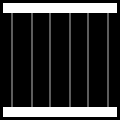

In [26]:
fingers_px =  [4, 4, 4, 4, 4, 4]

ctx = image.new_context()
ctx.stroke_style = FINGER_PAINT
f_origin_y = np.rint(bus_px + offset_px)
f_length = np.rint(ny - 2 * offset_px - 2 * bus_px)
n = len(fingers_px)
w = nx - 2 * offset_px  # width of mask
d = w / (2*n) # the half-spacing between fingers
f_x = [offset_px + d] # location of first grid finger
for idx in range(1, n):
    f_x.append(f_x[idx-1] + 2*d)

# Round the x locations to the nearest integer, this avoid
# the drawing tool kit from blending the colors
f_x = np.rint(np.array(f_x))


for f_origin_x, f_width in zip(f_x, fingers_px):
    ctx.stroke_segment(f_origin_x, f_origin_y, f_origin_x, f_origin_y + f_length)

save_image(image, "img3.bmp")